<a href="https://colab.research.google.com/github/marcopeduto/marcopeduto/blob/main/Labo_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

url = "https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/grades.csv"
grades = pd.read_csv(url)
grades.head()

,Grades
0,73.07
1,76.39
2,1.56
3,18.49
4,60.04


In [ ]:
num_observations = grades.shape[0]
print(num_observations)

150


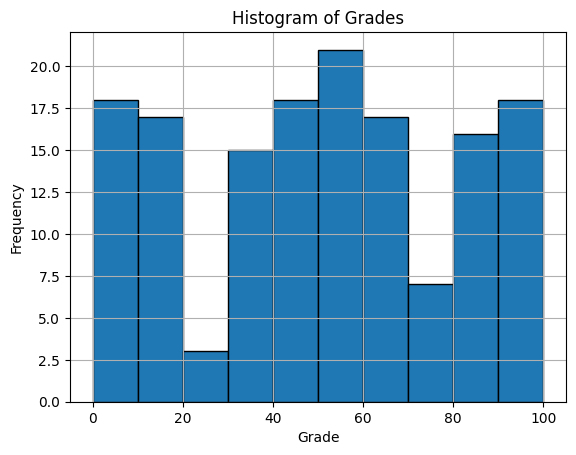

In [ ]:
plt.hist(grades['Grades'], edgecolor='black')
plt.title('Histogram of Grades')
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

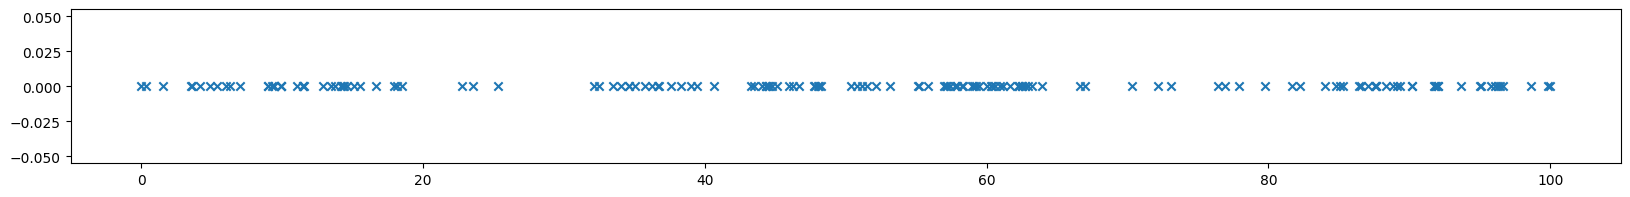

In [ ]:
plt.figure(figsize=(20,2))
plt.scatter(grades, np.zeros_like(grades), marker='x')

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(grades[['Grades']])

cluster_centers = kmeans.cluster_centers_
print("Cluster Centers: ", cluster_centers)

labels = kmeans.labels_
print("Labels: ", labels)

Cluster Centers:  [[73.99303797]
 [25.07225352]]
Labels:  [0 0 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 1 0 1 0 0 0 1
 1 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1
 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 1 1 0
 0 0 1 0 0 1 0 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 0 0 0 0 1 0 0 0
 0 0]


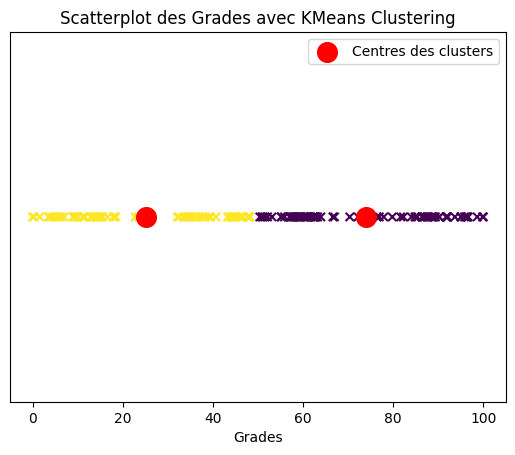

In [ ]:
plt.scatter(grades['Grades'], np.zeros_like(grades), c=kmeans.labels_, cmap='viridis', marker='x')

plt.scatter(kmeans.cluster_centers_, np.zeros_like(kmeans.cluster_centers_), c='red', s=200, marker='o', label='Centres des clusters')
plt.title("Scatterplot des Grades avec KMeans Clustering")
plt.xlabel("Grades")
plt.yticks([])
plt.legend()
plt.show()

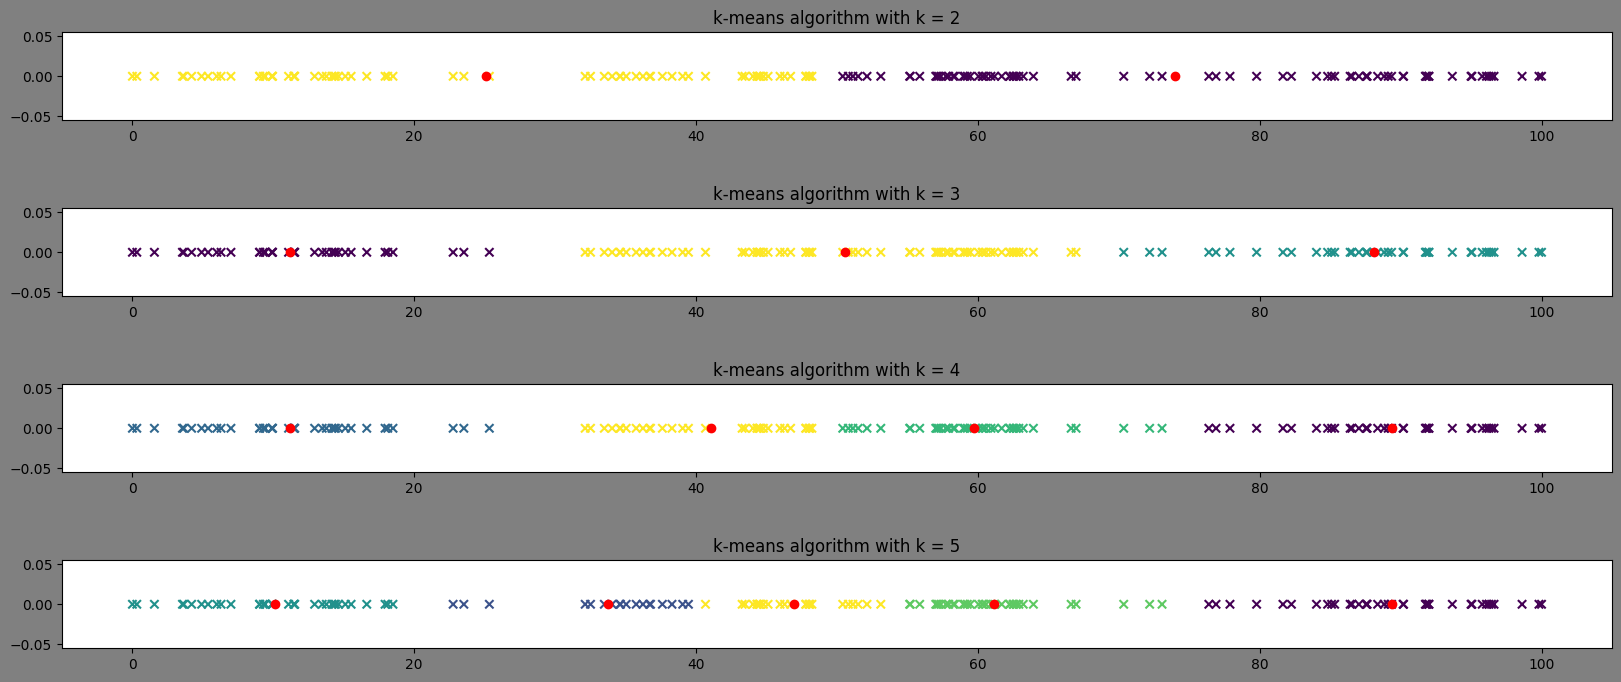

In [ ]:
# Fit k-means algorithm for different k
fig, ax = plt.subplots(4, 1, figsize=(20, 8), facecolor="grey")
for k in [2, 3, 4, 5]:
  # Create instance of class
  model = KMeans(n_clusters=k)
  # Fit model
  model.fit(grades)
  # Get centers of clusters
  centers = model.cluster_centers_
  # Get labels
  labels = model.labels_
  # Plot the points, colored by associated cluster
  ax[k-2].scatter(grades, np.zeros_like(grades), marker='x', c=labels, cmap='viridis')
  # Plot the center of each cluster
  ax[k-2].scatter(centers, np.zeros_like(centers), color='red')
  ax[k-2].set_title('k-means algorithm with k = ' + str(k))
plt.subplots_adjust(hspace=1)

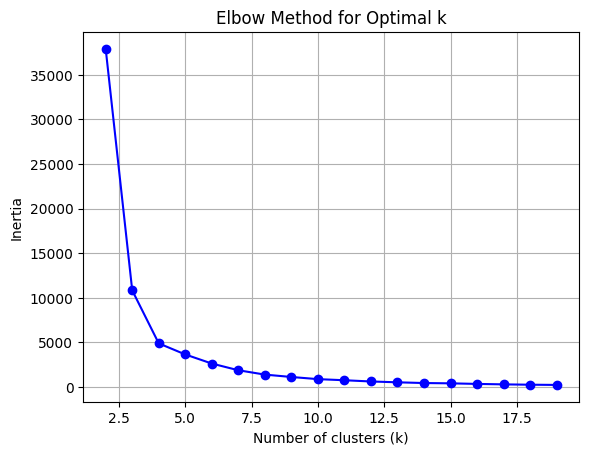

In [ ]:
inertia = []
for k in range(2, 20):
    model = KMeans(n_clusters=k, random_state=0, n_init=5)
    model.fit(grades.values.reshape(-1, 1))
    inertia.append(model.inertia_)

plt.plot(range(2, 20), inertia, marker='o', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

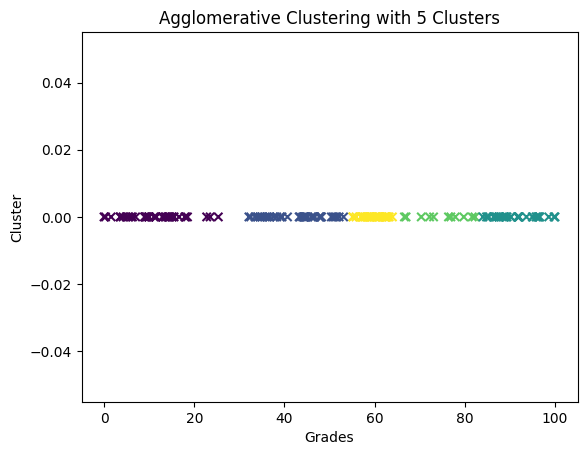

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='average')
labels = model.fit_predict(grades.values.reshape(-1, 1))
plt.scatter(grades, np.zeros_like(grades), marker='x', c=labels, cmap='viridis')

plt.title('Agglomerative Clustering with 5 Clusters')
plt.xlabel('Grades')
plt.ylabel('Cluster')
plt.show()

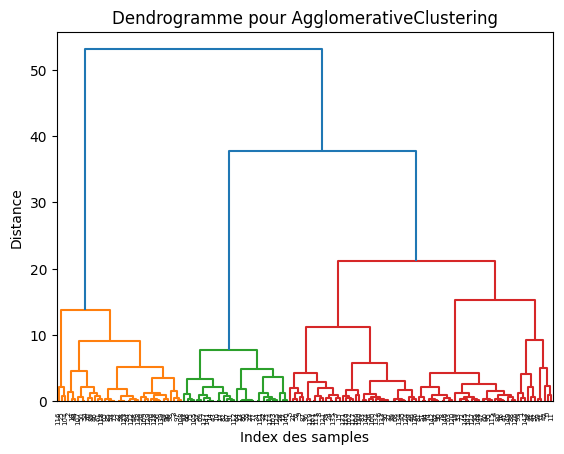

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(grades.values.reshape(-1, 1), method='average', metric='euclidean')
dendrogram(Z)

plt.title('Dendrogramme pour AgglomerativeClustering')
plt.xlabel('Index des samples')
plt.ylabel('Distance')
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster

clusters_at_30 = fcluster(Z, t=30, criterion='distance')
num_clusters_at_30 = len(np.unique(clusters_at_30))
print(f'Nombre de clusters formés à une distance de 30 : {num_clusters_at_30}')

Nombre de clusters formés à une distance de 30 : 3


Le nombre optimal de clusters est : 15
